In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [87]:
df = pd.read_csv("pima-indians-diabetes.csv", header=None)

df.columns = [
     "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"   
]

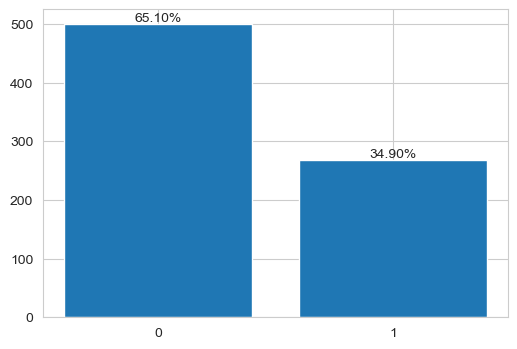

In [88]:
counts = df['Outcome'].value_counts()

percent = counts / counts.sum() * 100

plt.figure(figsize=(6,4))
plt.bar(counts.index.astype(str), counts.values)

for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{percent[i]:.2f}%", ha='center')

plt.show()

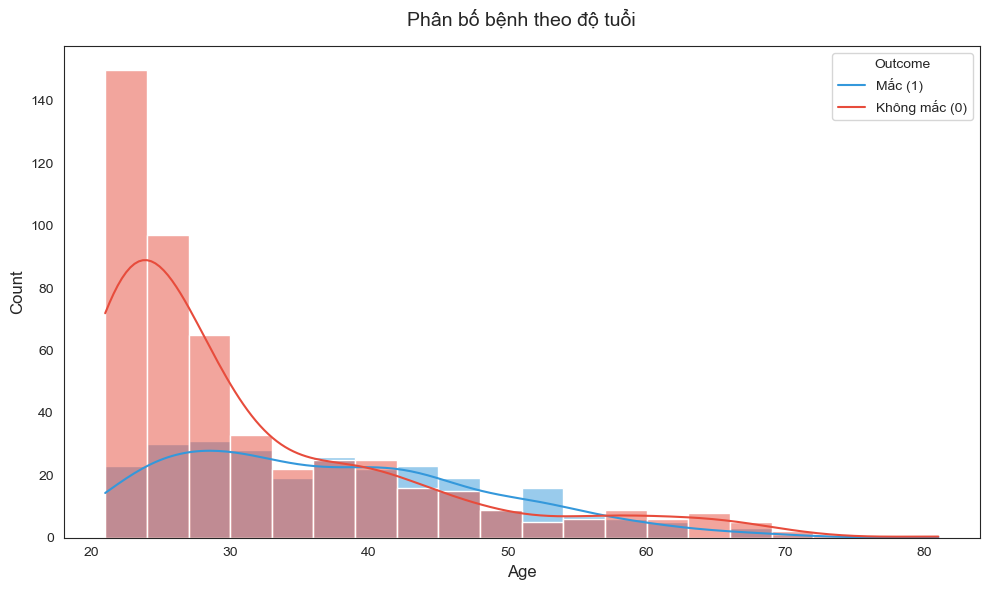

In [89]:
# 2. Cấu trúc giao diện
plt.figure(figsize=(10, 6))
sns.set_style("white") # Nền trắng tiêu chuẩn

ax = sns.histplot(
    data=df,
    x='Age',
    hue='Outcome',
    kde=True,
    element='bars',
    palette={0:'#e74c3c', 1: '#3498db'},
    alpha=0.5,
    bins=20
)

plt.title('Phân bố bệnh theo độ tuổi', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.legend(title='Outcome', labels=['Mắc (1)', 'Không mắc (0)'])

plt.tight_layout()
plt.show()
                    


In [90]:
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ['20-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '>60']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [91]:
# Tính BMI trung bình theo nhóm tuổi
bmi_mean_by_age = df.groupby('AgeGroup')['BMI'].mean().reset_index()


C:\Users\Dat\AppData\Local\Temp\ipykernel_5684\2503219588.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_mean_by_age = df.groupby('AgeGroup')['BMI'].mean().reset_index()


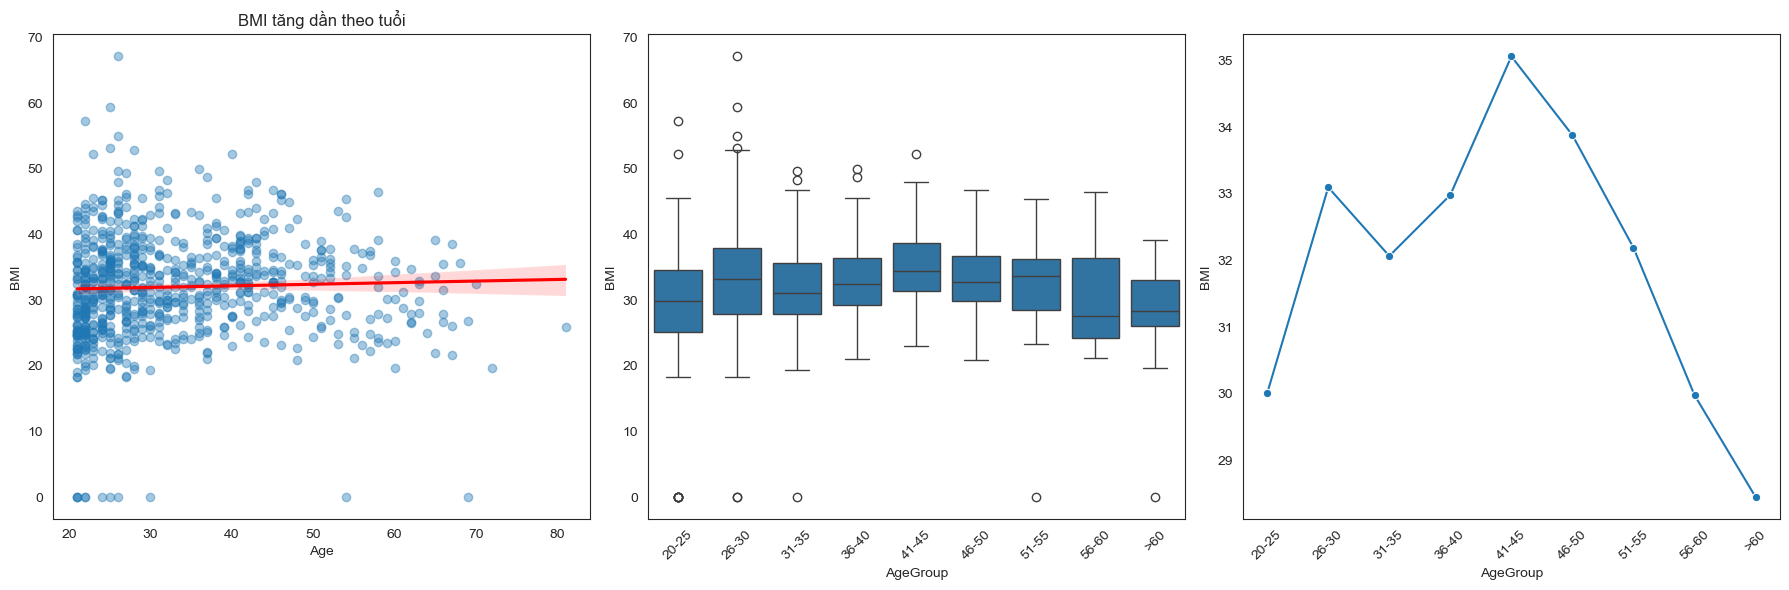

In [92]:
# Tạo layout
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
sns.set_style("whitegrid")

# === Biểu đồ 1 ===
sns.regplot(data=df, x='Age', y='BMI', ax=axes[0],
            scatter_kws={'alpha': 0.4},
            line_kws={'color': 'red'})
axes[0].set_title('BMI tăng dần theo tuổi')

# === Biểu đồ 2 ===
sns.boxplot(data=df, x='AgeGroup', y='BMI', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

# === Biểu đồ 3 ===
sns.lineplot(data=bmi_mean_by_age, x='AgeGroup', y='BMI', ax=axes[2], marker='o')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [93]:
# Tính trung bình glucose theo nhóm tuổi
glucose_mean = df.groupby('AgeGroup')['Glucose'].mean().reset_index()


C:\Users\Dat\AppData\Local\Temp\ipykernel_5684\3834878349.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_mean = df.groupby('AgeGroup')['Glucose'].mean().reset_index()


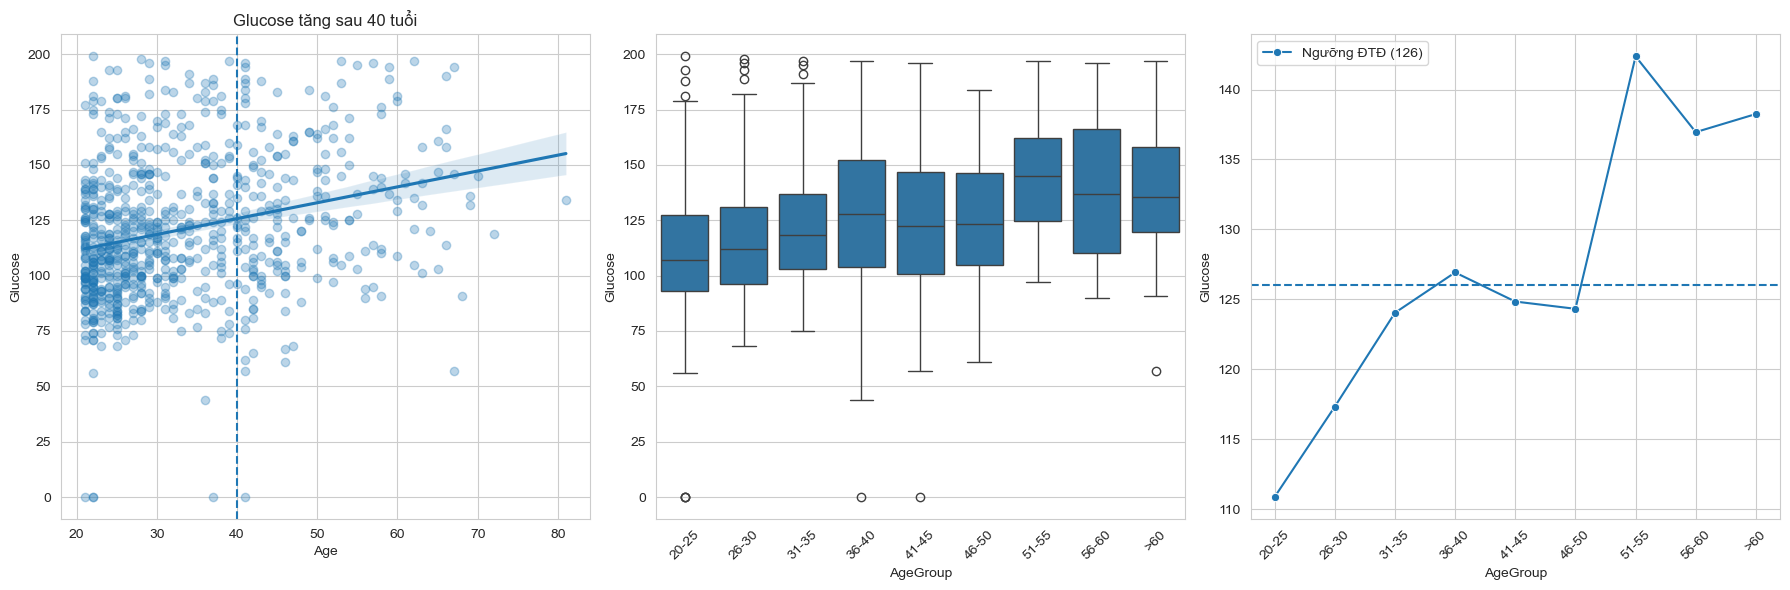

In [94]:
# Layout
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
sns.set_style("white")

# === Biểu đồ 1 ===
sns.regplot(data=df, x='Age', y='Glucose', ax=axes[0], scatter_kws={'alpha': 0.3})
axes[0].axvline(x=40, linestyle='--')  
axes[0].set_title('Glucose tăng sau 40 tuổi')

# === Biểu đồ 2 ===
sns.boxplot(data=df, x='AgeGroup', y='Glucose', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

# === Biểu đồ 3 ===
sns.lineplot(data=glucose_mean, x='AgeGroup', y='Glucose', ax=axes[2], marker='o')
axes[2].axhline(y=126, linestyle='--')
axes[2].legend(['Ngưỡng ĐTĐ (126)'])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [95]:
# Tính trung bình huyết áp
bp_mean = df.groupby('AgeGroup')['BloodPressure'].mean().reset_index()

C:\Users\Dat\AppData\Local\Temp\ipykernel_5684\285939620.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bp_mean = df.groupby('AgeGroup')['BloodPressure'].mean().reset_index()


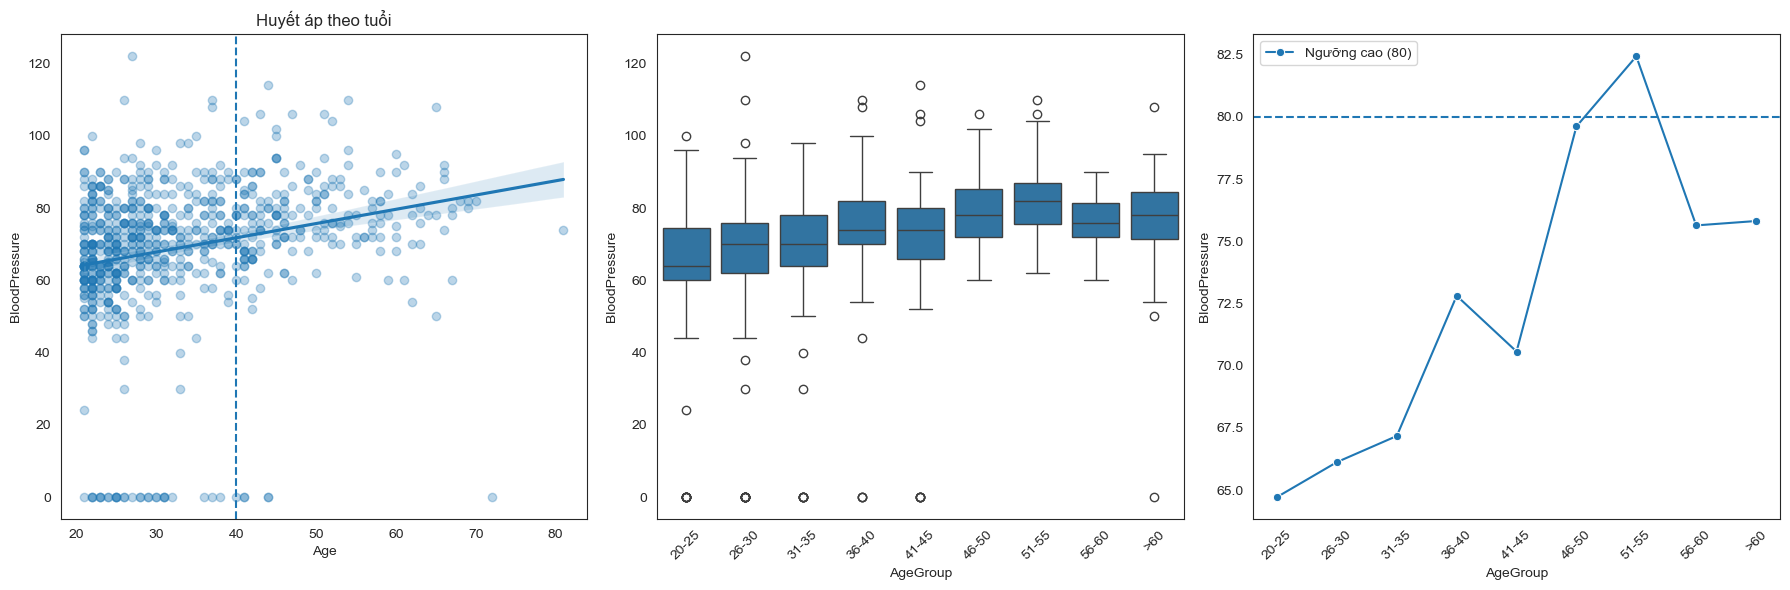

In [96]:
# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_style("whitegrid")

sns.regplot(data=df, x='Age', y='BloodPressure', ax=axes[0], scatter_kws={'alpha': 0.3})
axes[0].axvline(x=40, linestyle='--')
axes[0].set_title('Huyết áp theo tuổi')

sns.boxplot(data=df, x='AgeGroup', y='BloodPressure', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

sns.lineplot(data=bp_mean, x='AgeGroup', y='BloodPressure', ax=axes[2], marker='o')
axes[2].axhline(y=80, linestyle='--')
axes[2].legend(['Ngưỡng cao (80)'])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [97]:
# Tính trung bình glucose
glucose_mean = df.groupby('AgeGroup')['Glucose'].mean().reset_index()

C:\Users\Dat\AppData\Local\Temp\ipykernel_5684\2949271301.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  glucose_mean = df.groupby('AgeGroup')['Glucose'].mean().reset_index()


In [98]:
data = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=df.columns) 
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)


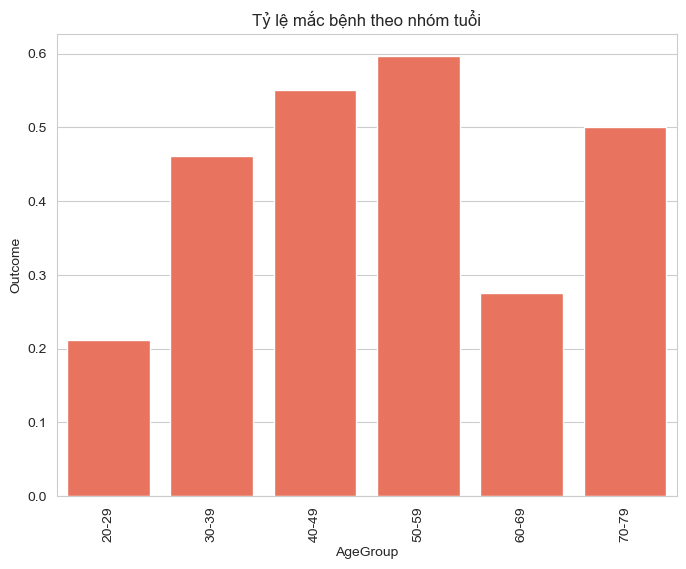

In [99]:
# 4. Tính toán tỷ lệ
age_disease_ratio = data.groupby('AgeGroup', observed=True)['Outcome'].mean().reset_index()

# 5. Vẽ biểu đồ
plt.figure(figsize=(8, 6))
sns.barplot(data=age_disease_ratio, x='AgeGroup', y='Outcome', color='#FF6347')
plt.xticks(rotation=90)
plt.title('Tỷ lệ mắc bệnh theo nhóm tuổi')
plt.show()

In [100]:
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif 18.5 <= bmi < 25:
        return 'Bình thường'
    elif 25 <= bmi < 30:
        return 'Thừa cân'
    else:
        return 'Béo phì'

data['BMI_Cat'] = data['BMI'].apply(classify_bmi)

# Sắp xếp thứ tự hiển thị của các cột trên biểu đồ
order = ['Béo phì', 'Thừa cân', 'Bình thường', 'Gầy']


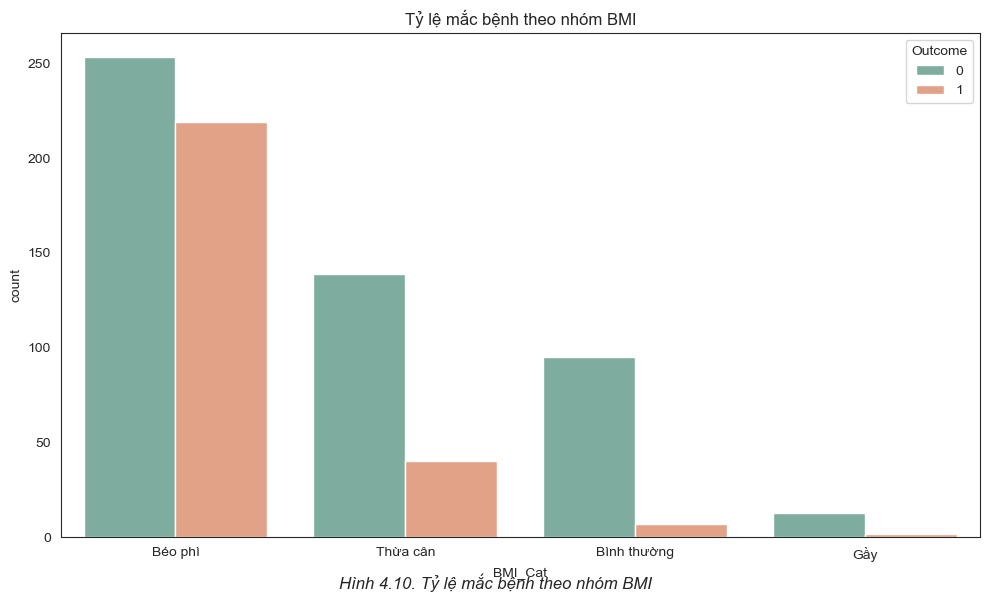

In [101]:
# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_style("white") # Nền trắng

# Vẽ biểu đồ countplot với hue là Outcome
ax = sns.countplot(data=data, x='BMI_Cat', hue='Outcome', order=order, 
                   palette={0: '#76b5a3', 1: '#f19c79'}) # Màu xanh và cam đỏ theo hình

# 4. Tùy chỉnh tiêu đề và nhãn
plt.title('Tỷ lệ mắc bệnh theo nhóm BMI', fontsize=12)
plt.xlabel('BMI_Cat')
plt.ylabel('count')

# Tùy chỉnh chú thích (Legend)
plt.legend(title='Outcome', labels=['0', '1'])

# Thêm tiêu thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 4.10. Tỷ lệ mắc bệnh theo nhóm BMI', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

plt.tight_layout()
plt.show()

In [102]:
data_2 = {
    'Nhóm BMI': ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phí'],
    'Tổng số': [4, 95, 170, 451],
    'Số ca mắc': [0, 7, 38, 203],
    'Tỷ lệ mắc (%)': [0.0, 7.0, 22.0, 45.0],
    'BMI trung bình': [18.2, 22.8, 27.5, 36.5]
}
df = pd.DataFrame(data_2)

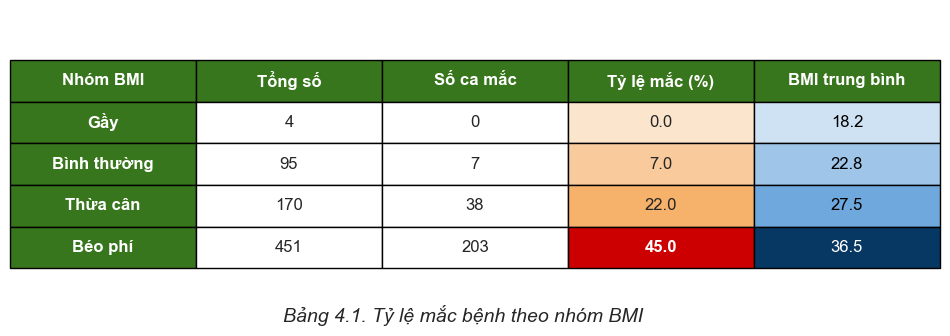

In [103]:
# 2. Thiết lập vẽ bảng bằng Matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off') # Tắt các trục tọa độ

# Tạo bảng
table = ax.table(cellText=df.values, 
                 colLabels=df.columns, 
                 cellLoc='center', 
                 loc='center')

# 3. Định dạng màu sắc (Format giống hình mẫu)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5) # Điều chỉnh độ rộng và chiều cao hàng

# Màu tiêu đề (Dòng đầu tiên - Màu xanh lá đậm)
for j in range(len(df.columns)):
    table[0, j].set_facecolor('#38761d')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Màu cột đầu tiên (Nhóm BMI - Màu xanh lá đậm)
for i in range(1, len(df) + 1):
    table[i, 0].set_facecolor('#38761d')
    table[i, 0].set_text_props(color='white', fontweight='bold')

# Màu cho cột 'Tỷ lệ mắc (%)' (Dải màu cam đỏ)
ratios_colors = ['#fce5cd', '#f9cb9c', '#f6b26b', '#cc0000']
for i, color in enumerate(ratios_colors, start=1):
    table[i, 3].set_facecolor(color)
    if i == 4: # Dòng cuối chữ trắng cho dễ đọc trên nền đỏ
        table[i, 3].set_text_props(color='white', fontweight='bold')

# Màu cho cột 'BMI trung bình' (Dải màu xanh dương)
bmi_colors = ['#cfe2f3', '#9fc5e8', '#6fa8dc', '#073763']
for i, color in enumerate(bmi_colors, start=1):
    table[i, 4].set_facecolor(color)
    table[i, 4].set_text_props(color='black' if i < 4 else 'white')

# 4. Thêm chú thích bên dưới
plt.figtext(0.5, 0.1, 'Bảng 4.1. Tỷ lệ mắc bệnh theo nhóm BMI', 
            wrap=True, horizontalalignment='center', fontsize=14, style='italic')

plt.show()

In [107]:
data_2 = pd.read_csv('pima-indians-diabetes.data.csv', header = None, names = df.columns)

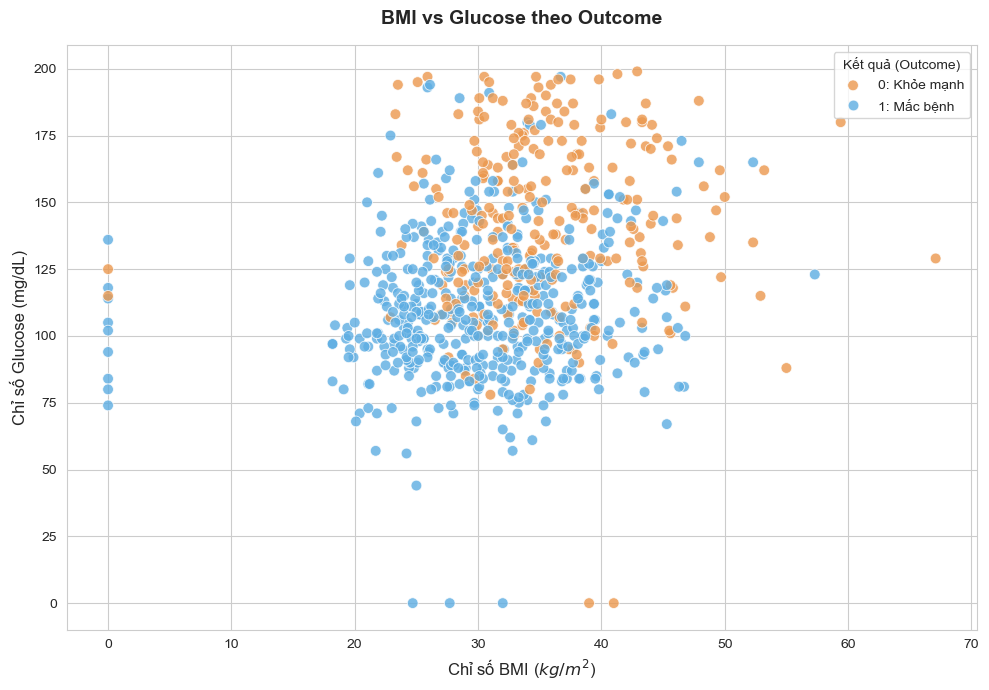

In [106]:
# 3. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid") # Thêm lưới nhẹ cho chuyên nghiệp

# 4. Vẽ biểu đồ phân tán (Scatter Plot)
# Chúng ta dùng x='BMI' và y='Glucose' vì đã đặt tên ở bước 2
scatter = sns.scatterplot(data=data, x='BMI', y='Glucose', hue='Outcome', 
                          palette={0: '#5dade2', 1: '#eb984e'}, 
                          alpha=0.8, edgecolor='w', s=60)

# 5. Tùy chỉnh tiêu đề và nhãn
plt.title('BMI vs Glucose theo Outcome', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Chỉ số BMI ($kg/m^2$)', fontsize=12)
plt.ylabel('Chỉ số Glucose (mg/dL)', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Kết quả (Outcome)', labels=['0: Khỏe mạnh', '1: Mắc bệnh'])

plt.tight_layout()
plt.show()

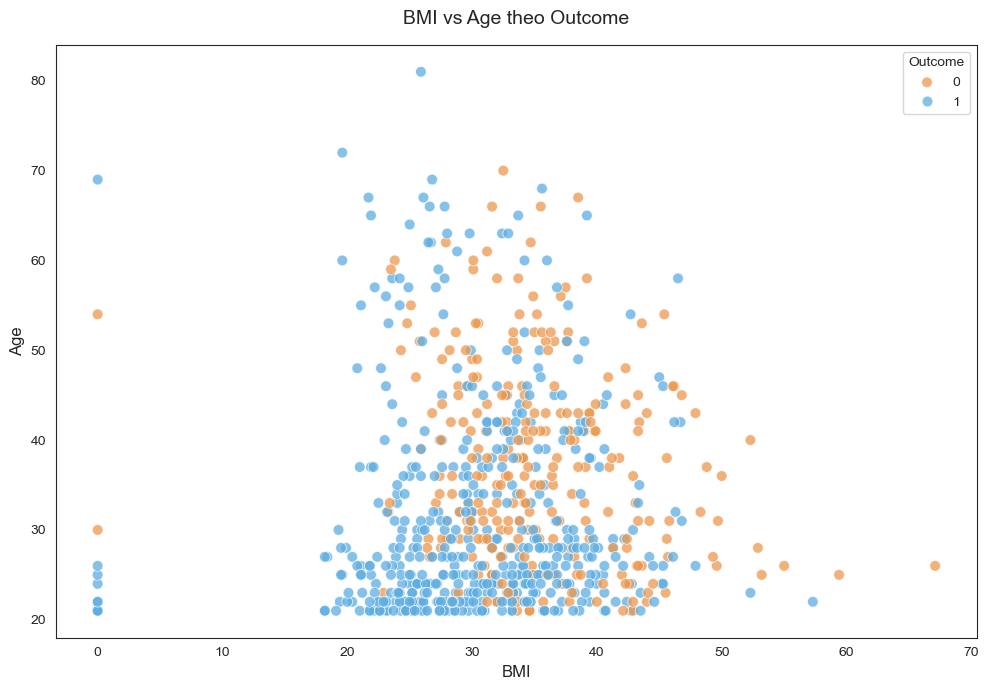

In [108]:
plt.figure(figsize=(10, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 4. Vẽ biểu đồ Scatter Plot
# x='BMI', y='Age': Các biến trục hoành và trục tung
# hue='Outcome': Phân chia màu sắc theo kết quả bệnh (0 và 1)
# alpha=0.7: Độ trong suốt giúp quan sát các điểm chồng lấp
# edgecolor='w': Viền trắng quanh các điểm để dễ phân biệt mật độ
scatter = sns.scatterplot(data=data, x='BMI', y='Age', hue='Outcome', 
                          palette={0: '#5dade2', 1: '#eb984e'}, 
                          alpha=0.75, edgecolor='w', s=60)

# 5. Tùy chỉnh tiêu đề và nhãn trục
plt.title('BMI vs Age theo Outcome', fontsize=14, pad=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Age', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Outcome', loc='upper right', labels=['0', '1'])

# 6. Hiển thị
plt.tight_layout()
plt.show()

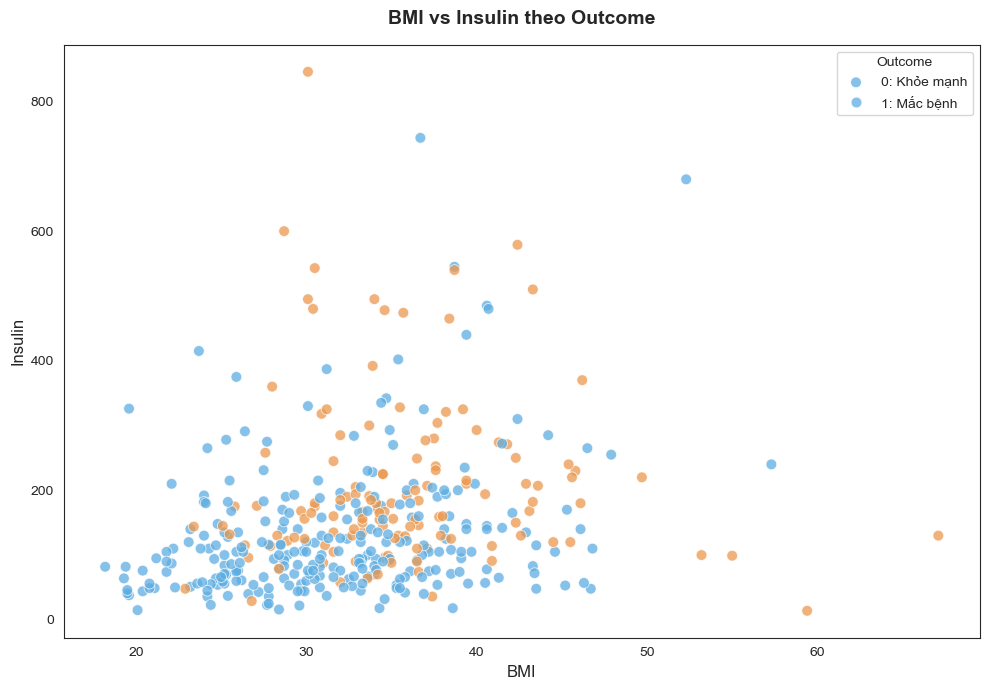

In [109]:
# 3. Lọc bỏ các giá trị nhiễu (tùy chọn nhưng nên làm)
# Trong bộ dữ liệu này, Insulin và BMI bằng 0 thường là dữ liệu thiếu
data_filtered = data[(data['BMI'] > 0) & (data['Insulin'] > 0)]

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 5. Vẽ biểu đồ Scatter Plot
# palette: Sử dụng dải màu Xanh dương và Cam tương đồng với hình mẫu
scatter = sns.scatterplot(data=data_filtered, x='BMI', y='Insulin', hue='Outcome', 
                          palette={0: '#5dade2', 1: '#eb984e'}, 
                          alpha=0.75, edgecolor='w', s=60)

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('BMI vs Insulin theo Outcome', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Outcome', loc='upper right', labels=['0: Khỏe mạnh', '1: Mắc bệnh'])


# 7. Hiển thị
plt.tight_layout()
plt.show()

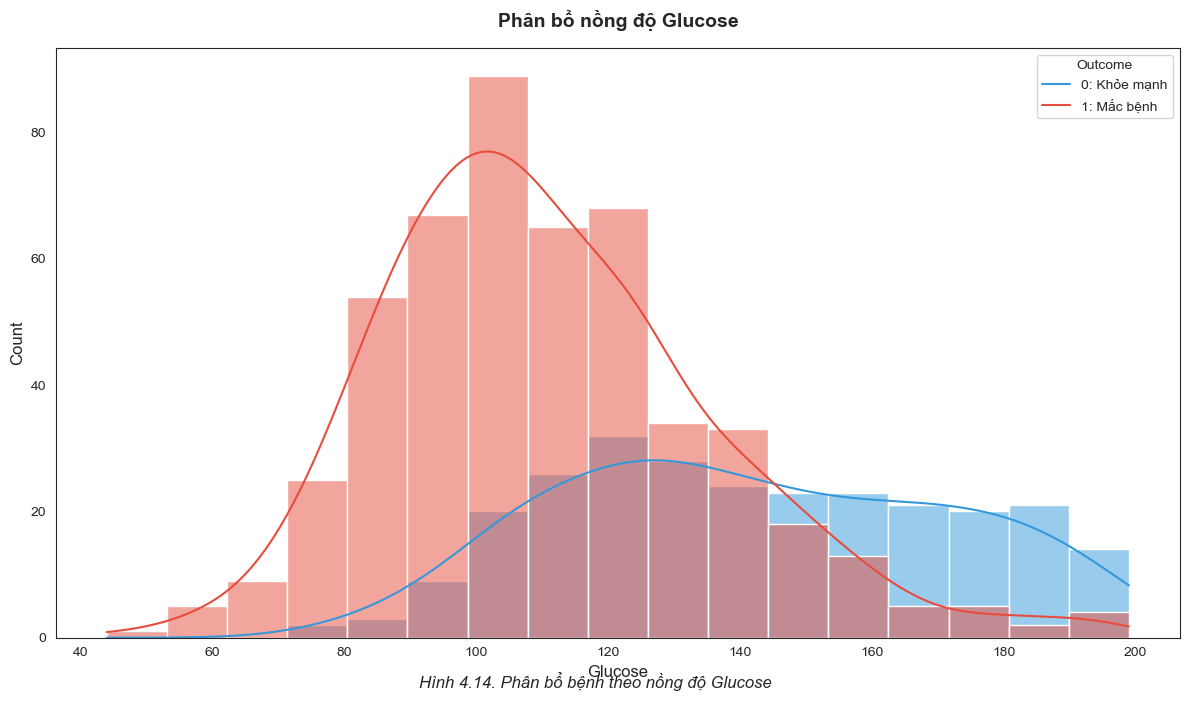

In [110]:
# 3. Lọc bỏ giá trị Glucose bằng 0 (thường là dữ liệu thiếu/nhiễu)
data = data[data['Glucose'] > 0]

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(12, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 5. Vẽ biểu đồ Histogram kết hợp đường KDE
# hue='Outcome': Phân loại theo kết quả bệnh (0 và 1)
# kde=True: Vẽ đường cong mật độ
# element='bars': Hiển thị dạng cột
# palette: Màu sắc (Đỏ cho 0, Xanh cho 1) tương đồng với hình mẫu
sns.histplot(data=data, x='Glucose', hue='Outcome', kde=True, 
             palette={0: '#e74c3c', 1: '#3498db'}, 
             alpha=0.5, element='bars')

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Phân bổ nồng độ Glucose', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Glucose', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Outcome', labels=['0: Khỏe mạnh', '1: Mắc bệnh'])

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 4.14. Phân bổ bệnh theo nồng độ Glucose', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 7. Hiển thị
plt.tight_layout()
plt.show()

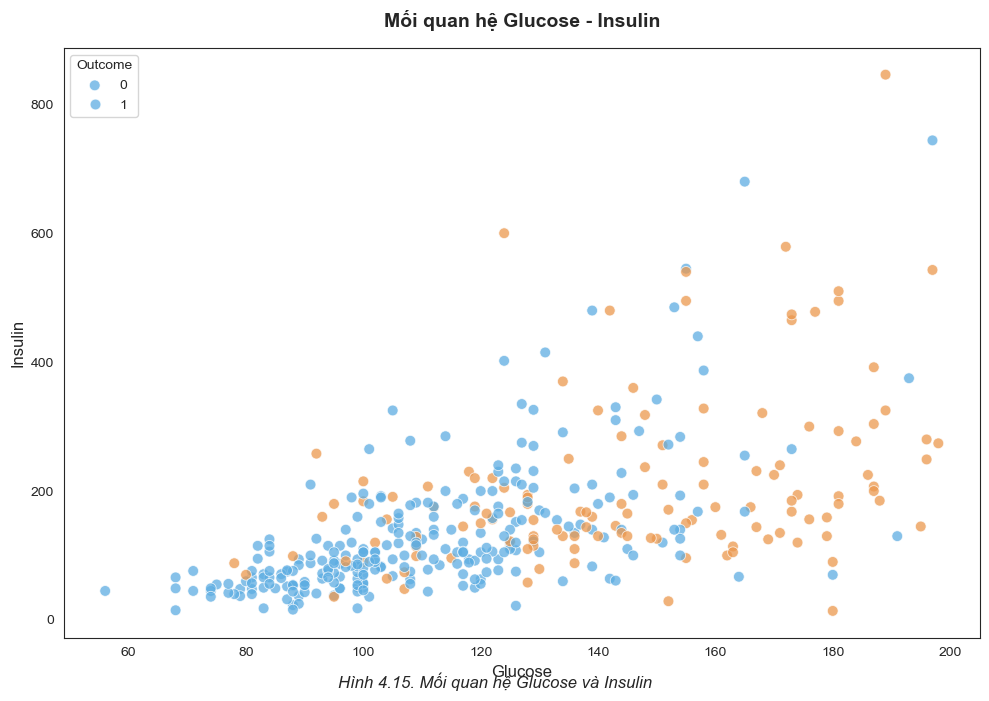

In [111]:
# 3. Lọc bỏ dữ liệu nhiễu (Glucose và Insulin bằng 0 thường là dữ liệu thiếu)
# Bước này giúp biểu đồ tập trung vào các giá trị thực tế hợp lý y khoa
data_filtered = data[(data['Glucose'] > 0) & (data['Insulin'] > 0)]

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 5. Vẽ biểu đồ Scatter Plot
# palette: Xanh dương (0) và Cam (1) tương đồng hình mẫu
scatter = sns.scatterplot(data=data_filtered, x='Glucose', y='Insulin', hue='Outcome', 
                          palette={0: '#5dade2', 1: '#eb984e'}, 
                          alpha=0.75, edgecolor='w', s=60)

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Mối quan hệ Glucose - Insulin', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Glucose', fontsize=12)
plt.ylabel('Insulin', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Outcome', loc='upper left', labels=['0', '1'])

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 4.15. Mối quan hệ Glucose và Insulin', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 7. Hiển thị
plt.tight_layout()
plt.show()

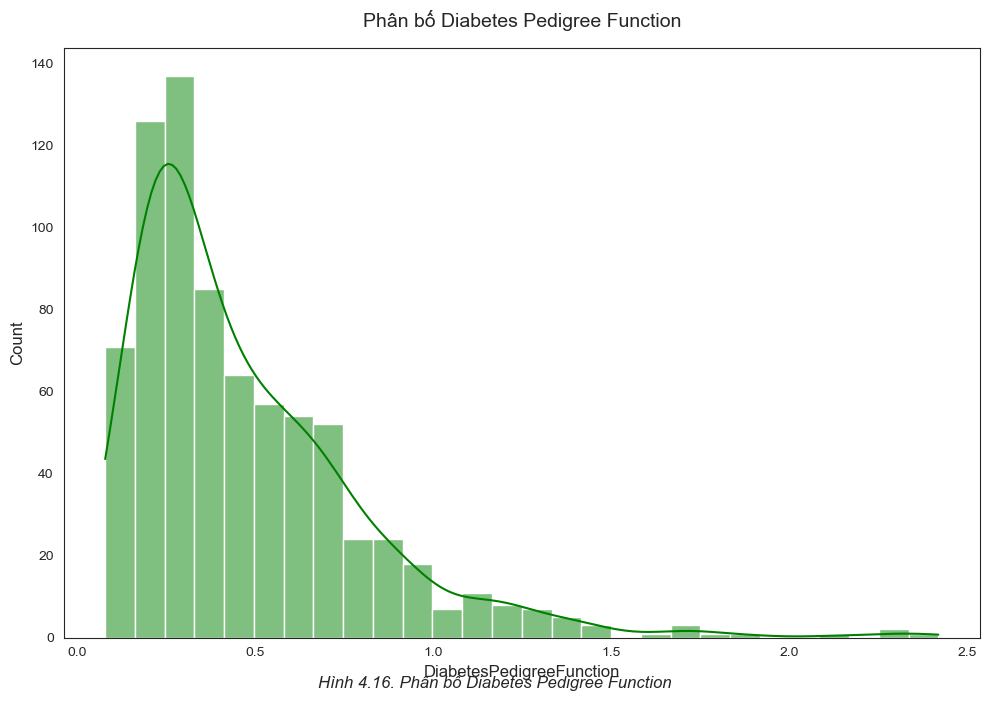

In [112]:
# 3. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn giống hình mẫu

# 4. Vẽ biểu đồ Histogram kết hợp đường KDE
# color='green': Chọn màu xanh lá cây đồng nhất cho cả cột và đường cong
# kde=True: Vẽ đường cong mật độ (Kernel Density Estimate)
# bins=20: Chia dữ liệu thành 20 cột (có thể điều chỉnh tùy độ mịn mong muốn)
sns.histplot(data=data, x='DiabetesPedigreeFunction', kde=True, 
             color='green', alpha=0.5)

# 5. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Phân bố Diabetes Pedigree Function', fontsize=14, pad=15)
plt.xlabel('DiabetesPedigreeFunction', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 4.16. Phân bố Diabetes Pedigree Function', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 6. Hiển thị
plt.tight_layout()
plt.show()

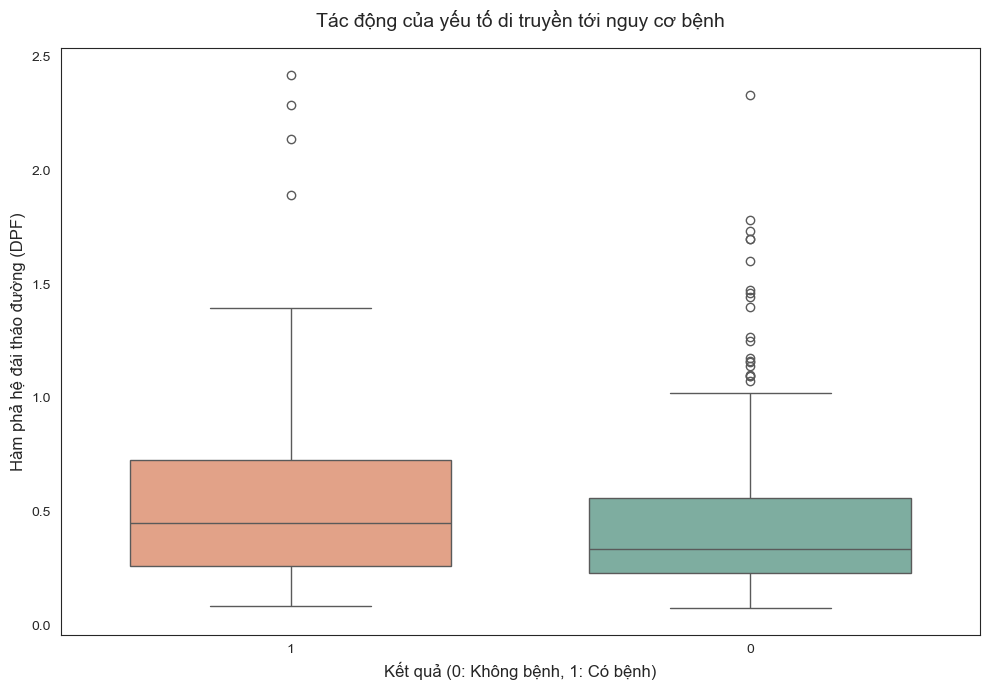

In [120]:
# 3. Cấu hình giao diện
plt.figure(figsize=(10, 7))
sns.set_style("white") 

# 4. Vẽ biểu đồ Boxplot (ĐÃ SỬA LỖI Ở ĐÂY)
# - Thêm hue='Outcome' để hết cảnh báo FutureWarning
# - Dùng {'0': ..., '1': ...} (có dấu nháy) để khớp với dữ liệu thực tế trong file
# - Đảm bảo ép kiểu Outcome về str để Seaborn không bị nhầm lẫn
data['Outcome'] = data['Outcome'].astype(str)

sns.boxplot(
    data=data, 
    x='Outcome', 
    y='DiabetesPedigreeFunction', 
    hue='Outcome',              # Bắt buộc phải có trong bản Seaborn mới
    palette={'0': '#76b5a3', '1': '#f19c79'}, # Dùng chuỗi để khớp với dữ liệu
    legend=False,               # Tắt chú thích vì trục X đã rõ ràng
    width=0.7
)

# 5. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Tác động của yếu tố di truyền tới nguy cơ bệnh', fontsize=14, pad=15)
plt.xlabel('Kết quả (0: Không bệnh, 1: Có bệnh)', fontsize=12)
plt.ylabel('Hàm phả hệ đái tháo đường (DPF)', fontsize=12)


# 6. Hiển thị
plt.tight_layout()
plt.show()

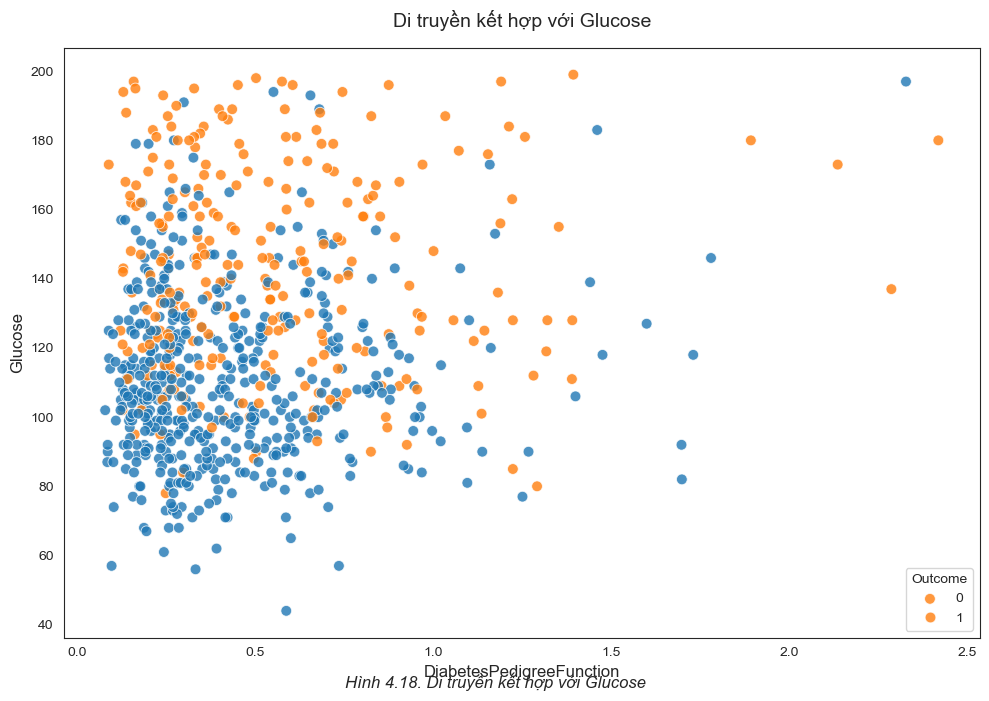

In [114]:
# 3. Tiền xử lý dữ liệu: Ép kiểu Outcome về chuỗi và lọc bỏ Glucose = 0 (nhiễu)
data['Outcome'] = data['Outcome'].astype(str)
data = data[data['Glucose'] > 0]

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 7))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 5. Vẽ biểu đồ Scatter Plot
# palette: Xanh dương (0) và Cam (1) tương đồng hình mẫu
# s=60: Kích thước điểm dữ liệu
# alpha=0.8: Độ trong suốt để thấy các điểm chồng lấp
scatter = sns.scatterplot(data=data, 
                          x='DiabetesPedigreeFunction', 
                          y='Glucose', 
                          hue='Outcome', 
                          palette={'0': '#1f77b4', '1': '#ff7f0e'}, 
                          alpha=0.8, 
                          edgecolor='w', 
                          s=60)

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Di truyền kết hợp với Glucose', fontsize=14, pad=15)
plt.xlabel('DiabetesPedigreeFunction', fontsize=12)
plt.ylabel('Glucose', fontsize=12)

# Chỉnh sửa chú thích (Legend)
plt.legend(title='Outcome', labels=['0', '1'], loc='lower right')

# Thêm chú thích hình bên dưới
plt.figtext(0.5, 0.01, 'Hình 4.18. Di truyền kết hợp với Glucose', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 7. Hiển thị
plt.tight_layout()
plt.show()

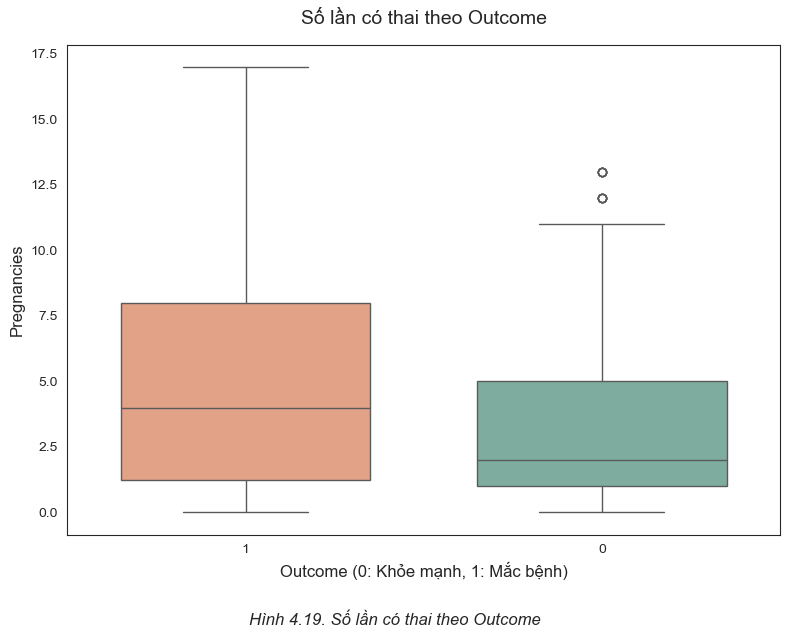

In [115]:
# 3. Tiền xử lý: Ép kiểu Outcome về chuỗi để palette hoạt động chính xác
data['Outcome'] = data['Outcome'].astype(str)

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(8, 6))
sns.set_style("white") # Nền trắng tiêu chuẩn

# 5. Vẽ biểu đồ Boxplot
# palette: Xanh ngọc (#76b5a3) cho nhóm 0 và Cam đất (#f19c79) cho nhóm 1
sns.boxplot(data=data, 
            x='Outcome', 
            y='Pregnancies', 
            hue='Outcome', 
            palette={'0': '#76b5a3', '1': '#f19c79'}, 
            width=0.7,
            legend=False)

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Số lần có thai theo Outcome', fontsize=14, pad=15)
plt.xlabel('Outcome (0: Khỏe mạnh, 1: Mắc bệnh)', fontsize=12)
plt.ylabel('Pregnancies', fontsize=12)

# Thêm chú thích hình bên dưới
plt.figtext(0.5, -0.05, 'Hình 4.19. Số lần có thai theo Outcome', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 7. Hiển thị
plt.tight_layout()
plt.show()

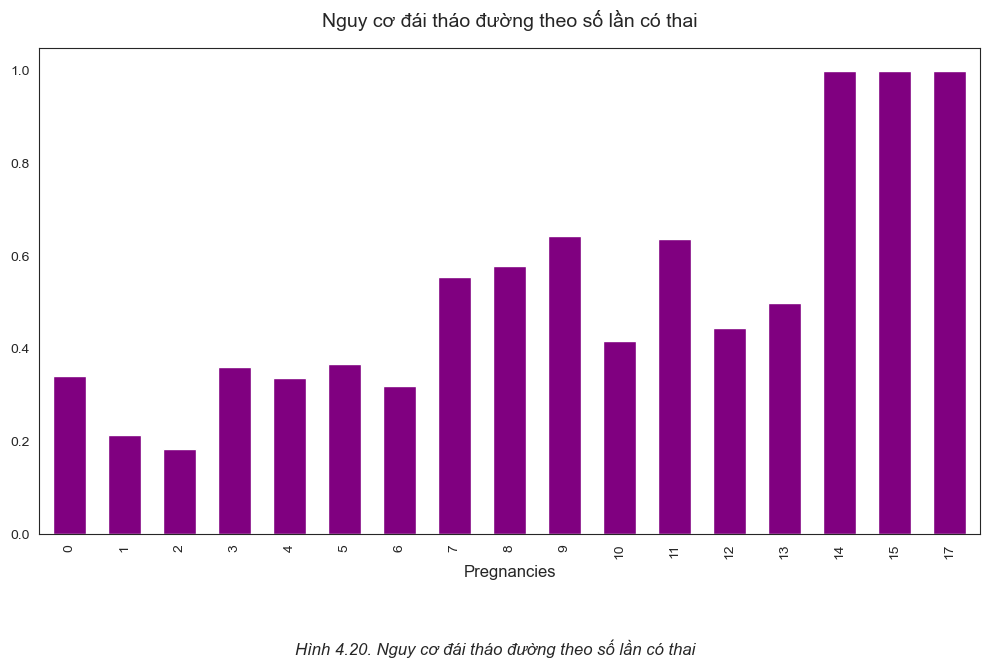

In [119]:
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv('pima-indians-diabetes.data.csv', header=None, names=column_names)

# 3. Tính toán tỷ lệ mắc bệnh (nguy cơ) theo số lần mang thai
# Nhóm theo Pregnancies và tính trung bình của Outcome
risk_by_pregnancy = data.groupby('Pregnancies')['Outcome'].mean()

# 4. Cấu hình giao diện vẽ hình
plt.figure(figsize=(10, 6))

# 5. Vẽ biểu đồ cột (Bar Chart)
# color='purple': Màu tím giống hình mẫu
risk_by_pregnancy.plot(kind='bar', color='purple', width=0.6)

# 6. Tùy chỉnh tiêu đề và nhãn trục
plt.title('Nguy cơ đái tháo đường theo số lần có thai', fontsize=14, pad=15)
plt.xlabel('Pregnancies', fontsize=12)
plt.ylabel('', fontsize=12) # Trục tung để trống nhãn như hình mẫu

# Thiết lập giới hạn trục tung từ 0.0 đến 1.0
plt.ylim(0, 1.05)

# Thêm chú thích hình bên dưới
plt.figtext(0.5, -0.1, 'Hình 4.20. Nguy cơ đái tháo đường theo số lần có thai', 
            wrap=True, horizontalalignment='center', fontsize=12, style='italic')

# 7. Hiển thị
plt.tight_layout()
plt.show()